# **Raporti — LAB05:**
## **Lënda:** Hyrje në Laborator
## **Kodi i laboratorit:** LAB05
## **Titulli:** Gjenerimi dhe Analiza e të Dhënave (Përshtatje Lineare)
## **Studentja:** Albana Hoxha
## **Grupi:** 1
## **Data e zhvillimit të laboratorit:** 08-04-2026
## **Data e dorëzimit:** 15-04-2026
## **Pedagogu:** Ervin Kafexhiu

## 1. Qëllimi 

Qëllimi i këtij laboratori është të gjenerojmë një grup të dhënash, të analizojmë lidhjen midis tyre dhe të gjejmë një vijë të drejtë që i përshtatet sa më mirë këtyre të dhënave. 

## 2. Gjenerimi i të dhënave

Të dhënat janë gjeneruar duke përdorur skriptin:


In [20]:
import numpy as np
import os

# ID e studentit
username = "Albana-1"

seed = sum(ord(c) for c in username)
np.random.seed(seed)

# Parametrat linearë
a = 2 + (seed % 3)     # pjerrësia
b = 5 + (seed % 5)     # prerja

# Të dhënat
x = np.linspace(1, 10, 20)
noise = np.random.normal(0, 1, size=len(x))
y = a * x + b + noise

# Ruajtja
os.makedirs("data", exist_ok=True)
np.savetxt("data/model.dat", np.column_stack((x, y)),
           delimiter=",", header="x,y", comments="")

print("model.dat u krijua!")

model.dat u krijua!


Ky skript krijon një dataset unik për çdo student duke përdorur:
- Parametra të ndryshëm linearë (a dhe b)
- Zhurmë të rastësishme (noise)

Dataset-i është:
- Unik për çdo student
- I riprodhueshëm (me të njëjtën ID)

In [22]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("data/model.dat", delimiter=",", skiprows=1)

x_Data = data[:, 0]
y_Data = data[:, 1]

##  3. Përshtatja lineare

Për të gjetur vijën që përshkruan më mirë të dhënat, përdorim regresion linear.

In [24]:
a, b = np.polyfit(x_Data, y_Data, 1)

print(f"Pjerrësia a = {a:.2f}")
print(f"Prerja b = {b:.2f}")

Pjerrësia a = 1.94
Prerja b = 9.37


## 4. Vizualizimi i të dhënave dhe modelit

Grafiku i mëposhtëm paraqet të dhënat eksperimentale dhe vijën e përshtatjes lineare.

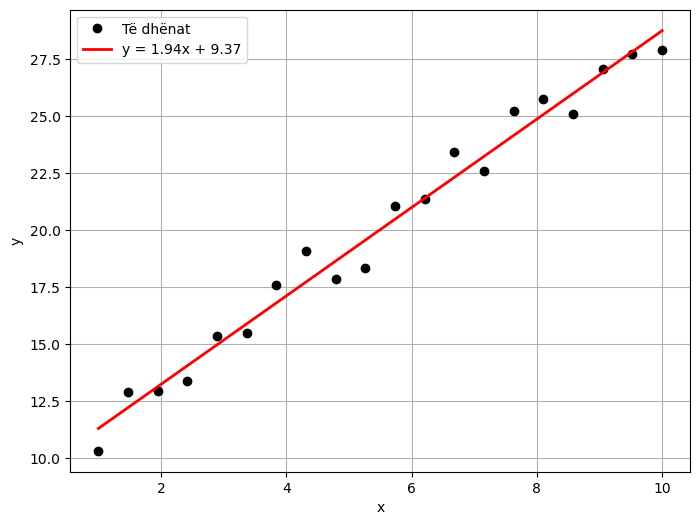

In [25]:
xfit = np.linspace(1, 10, 100)
yfit = a * xfit + b

plt.figure(figsize=(8,6))
plt.plot(x_Data, y_Data, 'ok', label='Të dhënat')
plt.plot(xfit, yfit, '-r', lw=2, label=f'y = {a:.2f}x + {b:.2f}')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

## 5. Analiza e mbetjeve (Residuals)

Mbetjet janë diferenca midis vlerave reale dhe atyre të modelit.
Ato ndihmojnë në vlerësimin e cilësisë së regresionit.

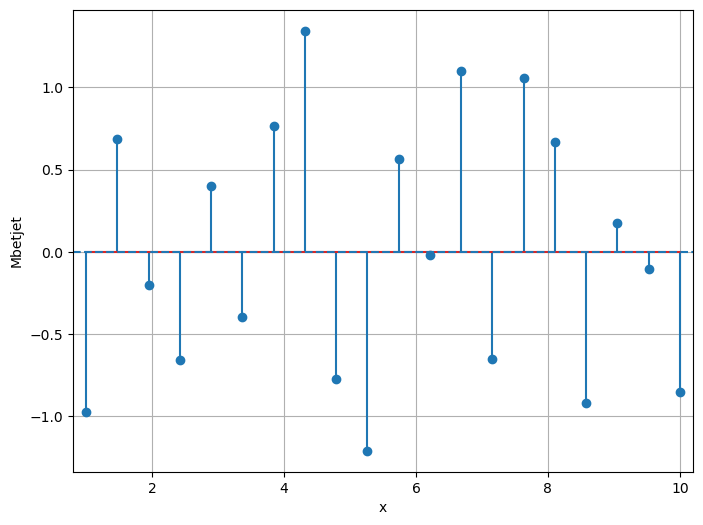

In [26]:
residuals = y_Data - (a * x_Data + b)

plt.figure(figsize=(8,6))
plt.stem(x_Data, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("x")
plt.ylabel("Mbetjet")
plt.xlim(0.8, 10.2)
plt.grid()
plt.show()

##  6. Interpretimi i rezultateve

- Pjerrësia (a) tregon lidhjen lineare midis x dhe y.
- Prerja (b) tregon vlerën e y kur x = 0.

Në grafikun e parë shohim që modeli linear përshtatet mirë me të dhënat.

Në grafikun e mbetjeve:
- Mbetjet janë të shpërndara rreth zeros
- Nuk vërehet ndonjë model i qartë

Kjo tregon se modeli linear është i përshtatshëm për këtë dataset.

## Përfundime

Në këtë laborator:
- U gjenerua një dataset unik dhe i riprodhueshëm
- U aplikua regresioni linear
- U analizua cilësia e modelit përmes mbetjeve

Rezultatet tregojnë se modeli linear përshkruan mirë të dhënat dhe është një përafrim i mirë i tyre.